In [1]:
import pandas as pd

train = pd.read_csv(r"C:\Users\HP\Downloads\perf_train.csv-1773986173225")
test = pd.read_csv(r"C:\Users\HP\Downloads\perf_test.csv-1773986175060")

In [3]:
train

,Employee_ID,Age,Gender,City,Education_Level,Department,Experience_Years,Monthly_Salary,Projects_Completed,Training_Hours,...,Job_Satisfaction,Manager_Rating,Overtime_Hours,Commute_Time_Min,Laptop_Issue_Count,Cafeteria_Rating,Internet_Stability,Last_Promotion_Years,Absenteeism_Days,Performance_Category
0,10001,49.0,Male,Bengaluru,Post Graduate,Sales,NaN,NaN,15.0,20.0,...,3.0,3.2,43.0,11.0,3.0,1.0,Good,2.1,1.0,Average Performer
1,10002,35.0,Female,Bengaluru,Post Graduate,Analytics,0.8,129555.0,15.0,163.0,...,4.0,2.3,43.0,128.0,6.0,5.0,Average,0.8,18.0,Low Performer
2,10003,28.0,Female,NaN,Graduate,Finance,12.7,55760.0,NaN,213.0,...,1.0,4.2,50.0,34.0,1.0,4.0,Poor,1.3,12.0,Average Performer
3,10004,41.0,Male,Hyderabad,Graduate,Sales,4.9,128174.0,NaN,209.0,...,2.0,4.5,78.0,168.0,7.0,5.0,Good,4.2,11.0,Average Performer
4,10005,39.0,Male,NaN,Graduate,Sales,1.2,145192.0,5.0,117.0,...,3.0,4.2,20.0,117.0,9.0,2.0,Excellent,2.5,24.0,Low Performer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,11996,49.0,Female,Kolkata,Post Graduate,NaN,16.7,85567.0,20.0,233.0,...,2.0,4.6,7.0,48.0,4.0,4.0,Average,6.7,24.0,Average Performer
1996,11997,26.0,Male,Bengaluru,NaN,Sales,2.1,80713.0,29.0,34.0,...,3.0,NaN,4.0,63.0,11.0,3.0,Poor,0.3,24.0,Low Performer
1997,11998,NaN,NaN,Hyderabad,Diploma,Sales,2.5,76639.0,NaN,27.0,...,2.0,2.4,65.0,NaN,11.0,5.0,Good,6.6,8.0,Low Performer
1998,11999,49.0,Male,Bengaluru,Graduate,Finance,1.1,121603.0,5.0,9.0,...,NaN,3.2,72.0,131.0,10.0,5.0,Average,7.2,17.0,Low Performer


In [4]:
test.head()

,Employee_ID,Age,Gender,City,Education_Level,Department,Experience_Years,Monthly_Salary,Projects_Completed,Training_Hours,...,Work_Life_Balance,Job_Satisfaction,Manager_Rating,Overtime_Hours,Commute_Time_Min,Laptop_Issue_Count,Cafeteria_Rating,Internet_Stability,Last_Promotion_Years,Absenteeism_Days
0,12001,43.0,Female,Delhi,Graduate,Operations,NaN,110905.0,23.0,225.0,...,NaN,2.0,2.9,64.0,45.0,2.0,1.0,Excellent,3.3,1.0
1,12002,39.0,Male,Hyderabad,Post Graduate,HR,17.5,20977.0,26.0,86.0,...,3.0,5.0,2.8,65.0,80.0,4.0,4.0,Average,4.3,0.0
2,12003,NaN,Male,Delhi,Graduate,Finance,NaN,133650.0,NaN,246.0,...,1.0,NaN,NaN,25.0,111.0,6.0,2.0,Average,1.9,4.0
3,12004,25.0,NaN,Hyderabad,Graduate,Sales,14.1,72641.0,7.0,NaN,...,5.0,3.0,4.9,30.0,134.0,9.0,2.0,Average,4.1,23.0
4,12005,39.0,Male,NaN,Post Graduate,Analytics,NaN,132465.0,10.0,56.0,...,2.0,3.0,4.3,50.0,99.0,1.0,4.0,Poor,7.1,2.0


### Missing Values

In [2]:
train.isnull().sum()

Employee_ID               0
Age                     127
Gender                   66
City                    211
Education_Level         194
Department              199
Experience_Years        253
Monthly_Salary          105
Projects_Completed      288
Training_Hours          298
Certifications          305
Work_Life_Balance       181
Job_Satisfaction        196
Manager_Rating          147
Overtime_Hours          190
Commute_Time_Min        195
Laptop_Issue_Count       67
Cafeteria_Rating        283
Internet_Stability      343
Last_Promotion_Years    164
Absenteeism_Days        319
Performance_Category      0
dtype: int64

### Handling Missing Values

In [3]:
# Numeric — fill with median from train
num_cols = ['Age', 'Experience_Years', 'Monthly_Salary', 'Projects_Completed', 'Manager_Rating', 'Overtime_Hours', 'Commute_Time_Min',
            'Laptop_Issue_Count', 'Cafeteria_Rating', 'Last_Promotion_Years', 'Absenteeism_Days',
            'Training_Hours', 'Certifications','Work_Life_Balance','Job_Satisfaction']

for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# Categorical — fill with mode from train
cat_cols = ['Gender', 'City', 'Department', 'Education_Level', 'Internet_Stability']

for col in cat_cols:
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)

# Confirm
print("Train nulls:", train.isnull().sum().sum())
print("Test nulls:", test.isnull().sum().sum())

Train nulls: 0
Test nulls: 0


### Visualisation

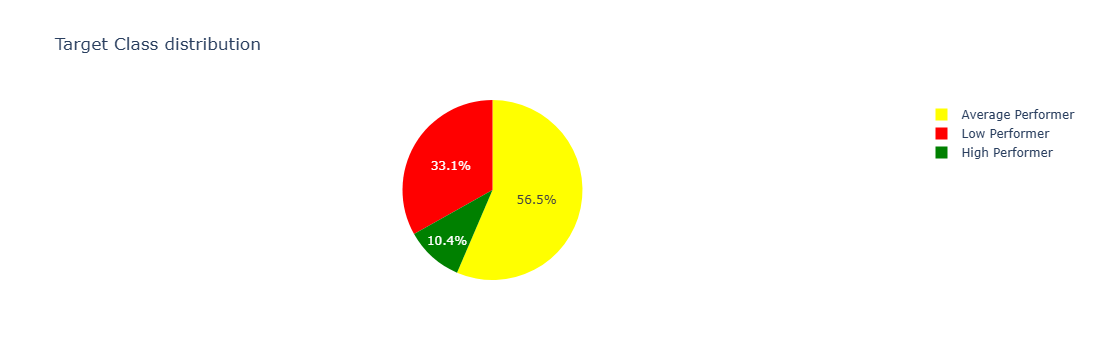

Performance_Category
Average Performer    1129
Low Performer         663
High Performer        208
Name: count, dtype: int64

In [4]:
import plotly.express as px 
fig = px.pie(train, names = 'Performance_Category', color= 'Performance_Category',
             color_discrete_map = {'High Performer' : 'Green',
                                   'Average Performer': 'Yellow',
                                   'Low Performer': 'Red'},
            title = 'Target Class distribution')
fig.show()

train.Performance_Category.value_counts()

### Numeric feature distributions by performance category

IndexError: index 9 is out of bounds for axis 0 with size 9

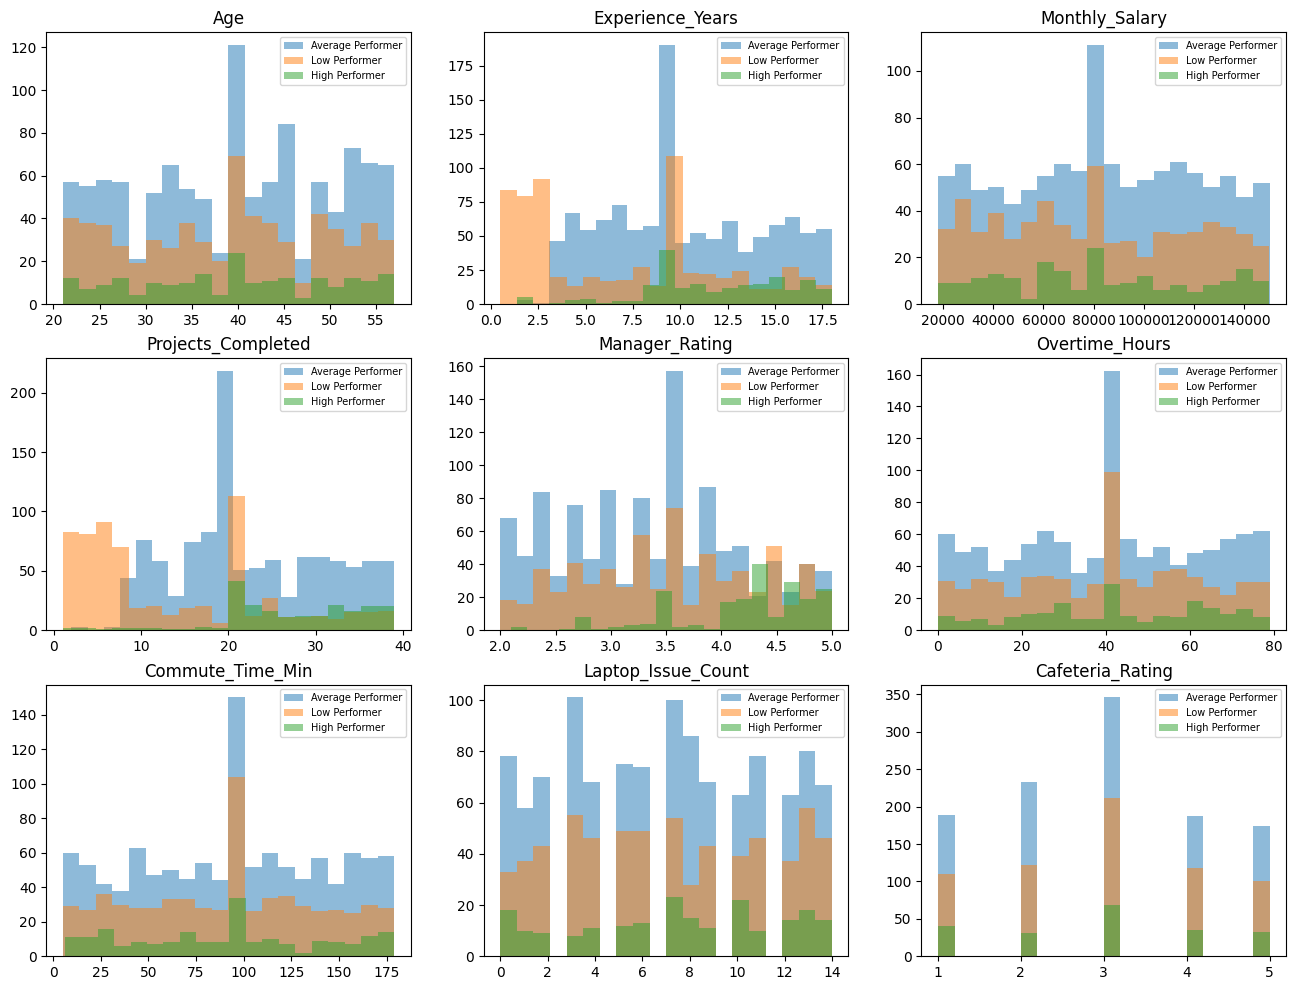

In [5]:
import matplotlib.pyplot as plt
num_cols = ['Age', 'Experience_Years', 'Monthly_Salary', 'Projects_Completed', 'Manager_Rating', 'Overtime_Hours', 'Commute_Time_Min',
            'Laptop_Issue_Count', 'Cafeteria_Rating', 'Last_Promotion_Years', 'Absenteeism_Days',
            'Training_Hours', 'Certifications','Work_Life_Balance','Job_Satisfaction']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for cat in train['Performance_Category'].unique():
        subset = train[train['Performance_Category'] == cat][col].dropna()
        axes[i].hist(subset, alpha=0.5, label=cat, bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distributions by Performance Category', fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Heatmap

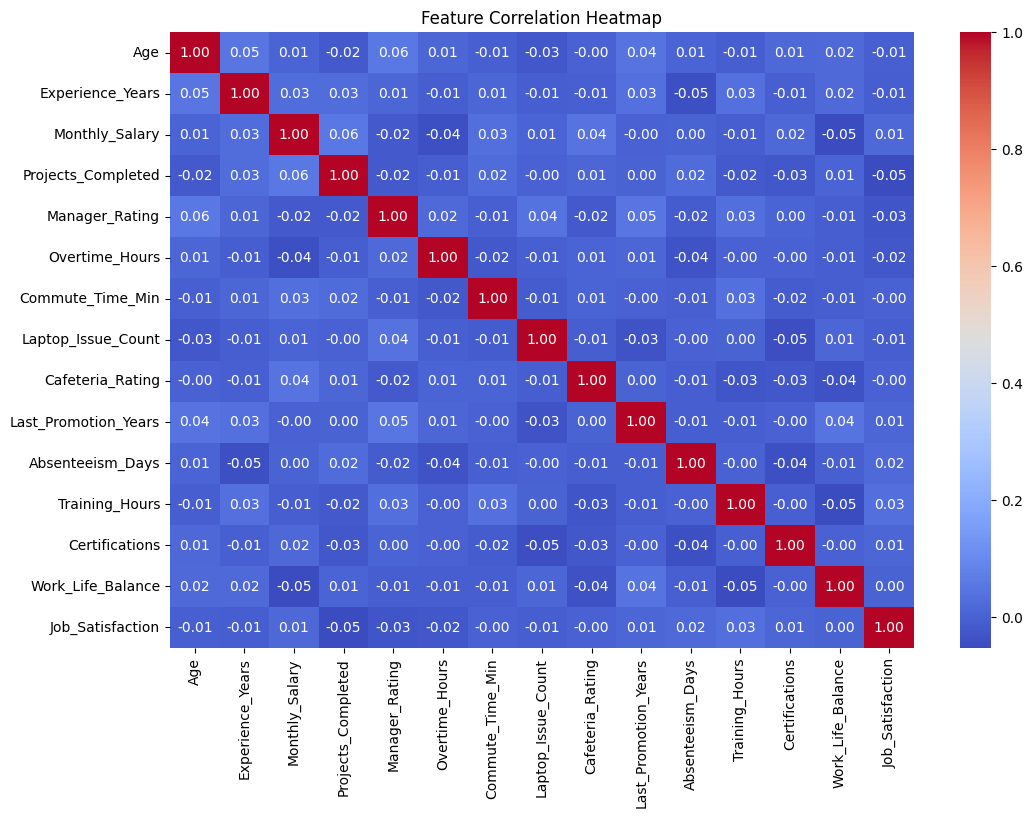

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### Boxplots

IndexError: index 8 is out of bounds for axis 0 with size 8

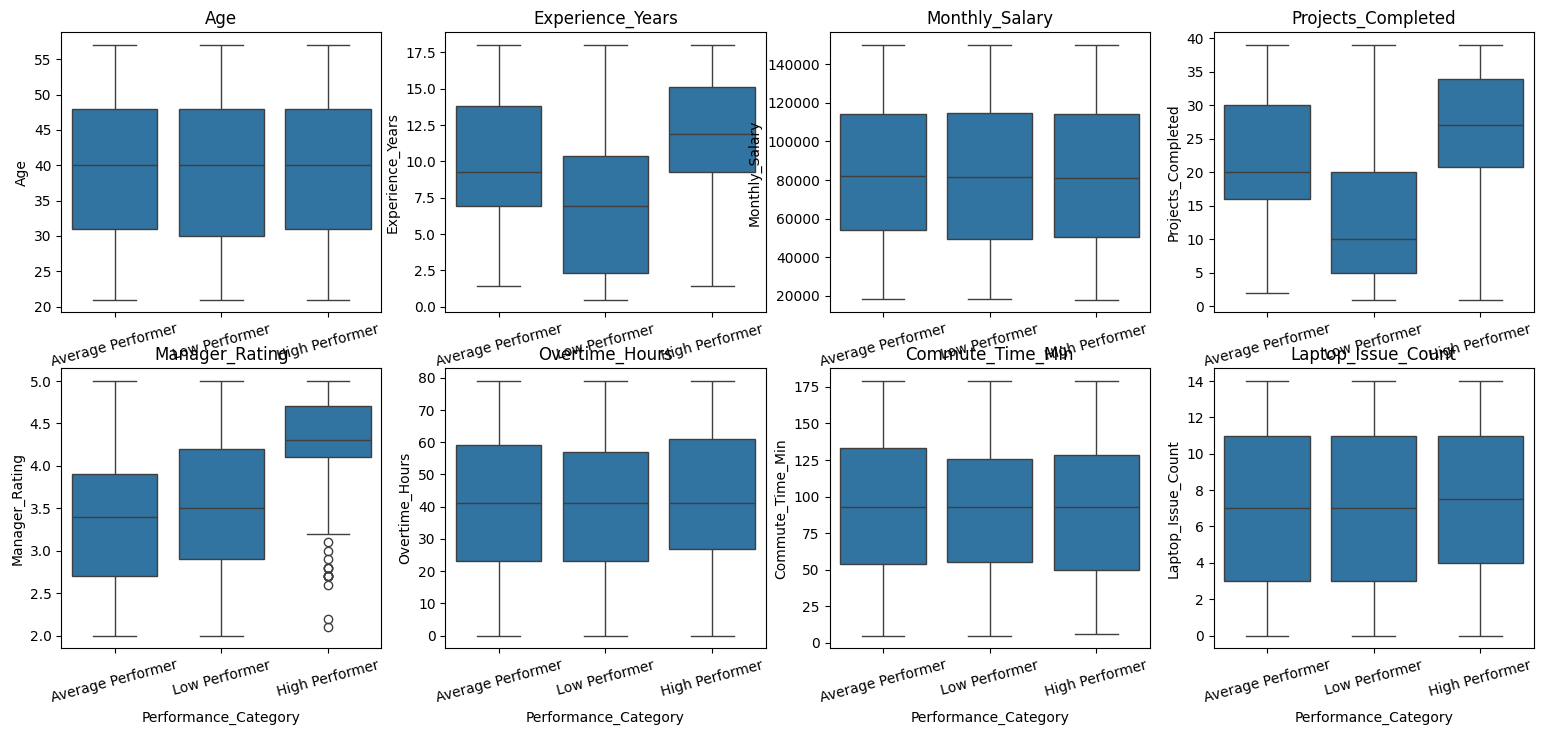

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x='Performance_Category', y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=15)
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots by Performance Category', fontsize= 16)
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()
plt.tight_layout(pad = 5.0)

### Label Encoder

In [8]:
from sklearn.preprocessing import LabelEncoder

# Separate encoder per categorical column
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    label_encoders[col] = le

# Separate encoder for target only
le_target = LabelEncoder()
y = le_target.fit_transform(train['Performance_Category'])

print("Classes:", le_target.classes_)

Classes: ['Average Performer' 'High Performer' 'Low Performer']


### Train/Val Split

In [9]:
from sklearn.model_selection import train_test_split

X = train.drop(['Employee_ID', 'Performance_Category'], axis=1)
X_test = test.drop(['Employee_ID'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (1600, 20)
Val shape: (400, 20)


### SMOTETomek (on train only)

In [10]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

import pandas as pd
print("Before:", pd.Series(y_train).value_counts().to_dict())
print("After :", pd.Series(y_train_res).value_counts().to_dict())

Before: {0: 903, 2: 530, 1: 167}
After : {1: 733, 2: 722, 0: 690}


### Train XGBoost 

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train_res, y_train_res)
print("Training done")

Training done


=== Classification Report ===
                   precision    recall  f1-score   support

Average Performer       0.87      0.96      0.91       226
   High Performer       0.74      0.63      0.68        41
    Low Performer       0.95      0.82      0.88       133

         accuracy                           0.88       400
        macro avg       0.85      0.80      0.83       400
     weighted avg       0.88      0.88      0.88       400



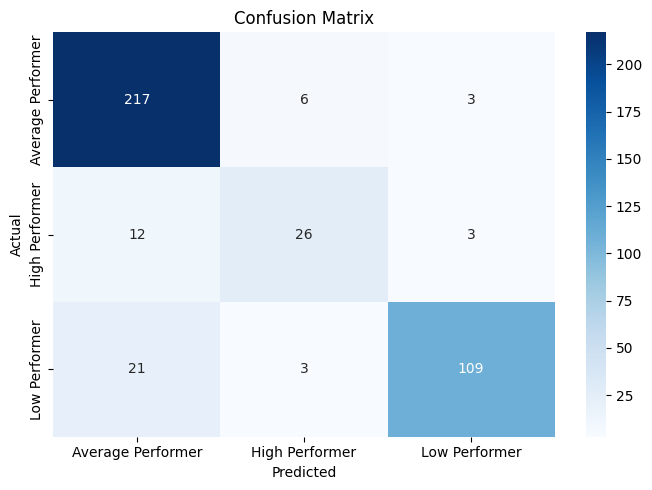

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)

print("=== Classification Report ===")
print(classification_report(y_val, y_pred, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Cross Validation

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')

print(f"CV F1 Scores : {scores.round(4)}")
print(f"Mean F1      : {scores.mean():.4f}")
print(f"Std Dev      : {scores.std():.4f}")

CV F1 Scores : [0.876  0.9039 0.8494 0.8799 0.9077]
Mean F1      : 0.8834
Std Dev      : 0.0211


### Feature Importance

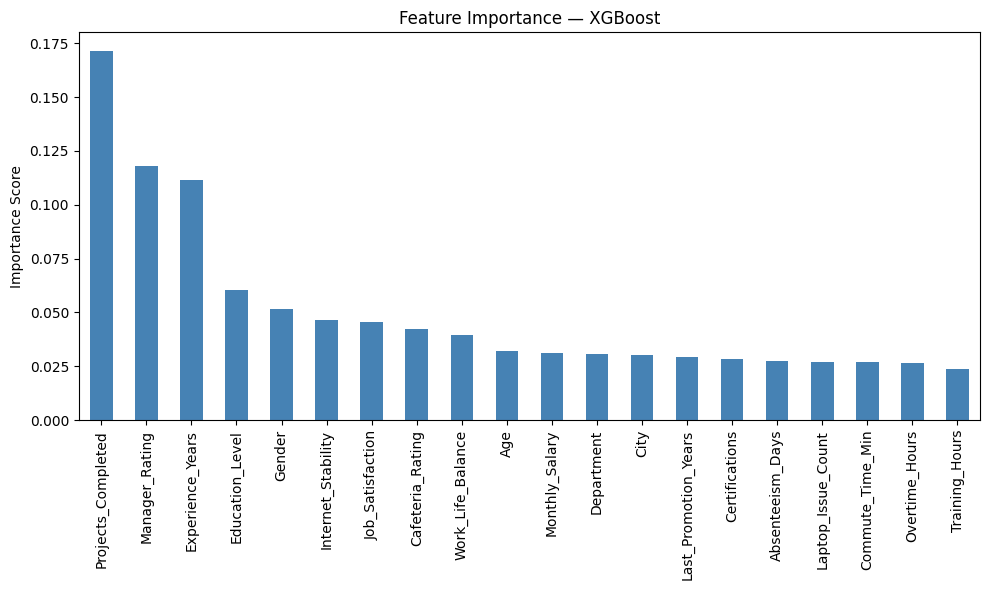

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
test_pred = model.predict(X_test)
test_pred_labels = le_target.inverse_transform(test_pred)

submission = pd.DataFrame({
    'Employee_ID': test['Employee_ID'],
    'Performance_Category': test_pred_labels
})

save_path = r"C:\Users\HP\Desktop\submission.csv"  
submission.to_csv(save_path, index=False)
print("Saved to Desktop!")
print(submission.head(10))
print(submission['Performance_Category'].value_counts())

Saved to Desktop!
   Employee_ID Performance_Category
0        12001    Average Performer
1        12002    Average Performer
2        12003    Average Performer
3        12004        Low Performer
4        12005    Average Performer
5        12006        Low Performer
6        12007    Average Performer
7        12008    Average Performer
8        12009    Average Performer
9        12010    Average Performer
Performance_Category
Average Performer    325
Low Performer        125
High Performer        50
Name: count, dtype: int64


#### Saving Model

In [16]:
import pickle

# Save everything
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('le_target.pkl', 'wb') as f:
    pickle.dump(le_target, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("All saved! ✅")

All saved! ✅


In [21]:
import pickle, os

save_folder = r"C:\Users\HP\Desktop\employee-performance_backend"

with open(os.path.join(save_folder, 'model.pkl'), 'wb') as f:
    pickle.dump(model, f)

with open(os.path.join(save_folder, 'le_target.pkl'), 'wb') as f:
    pickle.dump(le_target, f)

with open(os.path.join(save_folder, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)

print("All pkl files saved to backend folder! ✅")

All pkl files saved to backend folder! ✅
